In [32]:
import rocketpy
from datetime import datetime, timedelta
thrust_curve = "../data/motor_file/AeroTech_M2400T.eng"

https://docs.rocketpy.org/en/latest/user/rocket/rocket.html


Gravity Details

Acceleration of gravity at surface level:    9.8014 m/s²
Acceleration of gravity at  13.770 km (ASL): 9.7597 m/s²


Launch Site Details

Launch Date: 2026-04-18 14:00:00 UTC | 2026-04-18 10:00:00 America/New_York
Launch Site Latitude: 40.38677°
Launch Site Longitude: -87.51128°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 456604.17 W    4470812.02 N
Launch Site UTM zone: 16T
Launch Site Surface Elevation: 215.0 m


Atmospheric Model Details

Atmospheric Model Type: Windy
Windy Maximum Height: 13.770 km

Surface Atmospheric Conditions

Surface Wind Speed: 9.62 m/s
Surface Wind Direction: 316.25°
Surface Wind Heading: 136.25°
Surface Pressure: 987.99 hPa
Surface Temperature: 281.22 K
Surface Air Density: 1.224 kg/m³
Surface Speed of Sound: 336.17 m/s


Earth Model Details

Earth Radius at Launch site: 6369.20 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospheric Model Plots



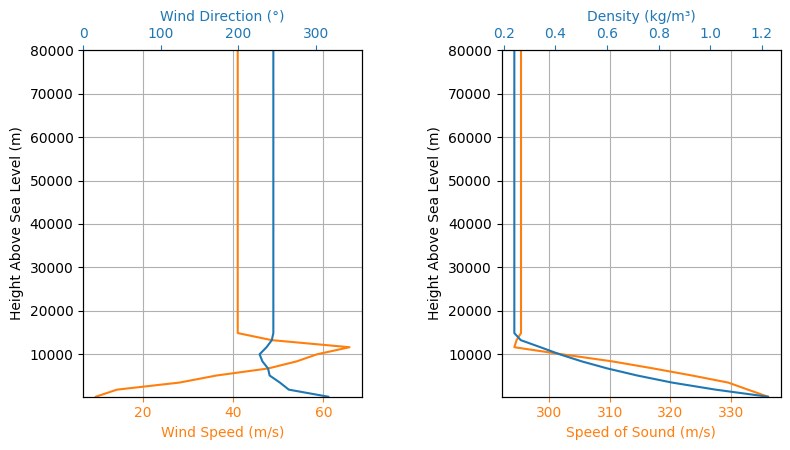

In [33]:
tomorrow = datetime.now() + timedelta(days=1)

env = rocketpy.Environment(
    latitude= 40.386772,
    longitude= -87.511283,
    elevation= 216.10,
    #date = tomorrow
    date=datetime(2026, 4, 18, 10, 0, 0),
    timezone="America/New_York"
)
env.set_atmospheric_model(type="Windy", file="GFS")##(type="standard_atmosphere")##, file="GFS")

env.info()

In [38]:
#calculated from ORK component mass distribution and simulation data
Control_Freak = rocketpy.Rocket(
    radius = 0.131/2,    #m
    mass   = 12,     #kg dry mass
    inertia=(6.93, 6.93, 0.057), #Pitch, Yaw, Roll in kg*m^2
    power_off_drag='/Users/chenhiko/Documents/GitHub/LRI/FV-Controls/rockets/Control_Freak/data/drag/CD_Power-off.csv', #m^2, from ORK simulation
    power_on_drag='/Users/chenhiko/Documents/GitHub/LRI/FV-Controls/rockets/Control_Freak/data/drag/CD_Power-on.csv', #m^2, from ORK simulation
    center_of_mass_without_motor=1.68, #m from nose tip
    coordinate_system_orientation="nose_to_tail",
 )

#AeroTech M2400T / RMS-98/7680

"""AeroTech_M2400T.eng"""


nose_cone = Control_Freak.add_nose(
    length=0.724, #m
    kind="von karman",
    position=0
)

#main fins
fin_set = Control_Freak.add_trapezoidal_fins(
    n=4,
    root_chord=0.305,
    tip_chord=0.152,
    span=0.133,
    position=2.459,
    cant_angle=0,
    airfoil=None,
    sweep_length = 0.234 
)

#canards
canards = Control_Freak.add_trapezoidal_fins(
    n=2,
    root_chord=0.0508,
    tip_chord=0.0127,
    span=0.0635,
    position=1.04,
    sweep_angle = 0.001,
    cant_angle = 0,
)

tail = Control_Freak.add_tail(
    top_radius = 0.131/2,
    bottom_radius = 0.102/2,
    length = 0.0762,
    position = 2.7938,
)


rail_buttons = Control_Freak.set_rail_buttons(
    upper_button_position=1.727,
    lower_button_position=2.692,
    angular_position=45,
)

""" main = Control_Freak.add_parachute(
    name="Main",
    cd_s=7.868,
    trigger=304.8,
    sampling_rate=105,
    radius= 1.0668,
    height=1.8161,
    porosity=0.01,
) """

""" drogue = Control_Freak.add_parachute(
    name="Drogue",
    cd_s=0.684,
    trigger="apogee",
    sampling_rate=105,
    radius=0.381,
    height=2.0193,
    porosity=0.01,
) """




' drogue = Control_Freak.add_parachute(\n    name="Drogue",\n    cd_s=0.684,\n    trigger="apogee",\n    sampling_rate=105,\n    radius=0.381,\n    height=2.0193,\n    porosity=0.01,\n) '

In [39]:
motor = rocketpy.SolidMotor(
    thrust_source=thrust_curve,
    dry_mass=2.799,
    dry_inertia=(0.08481, 0.08481, 0.00336),  # (I_11, I_22, I_33)
    nozzle_radius=0.024,
    grain_number=3,
    grain_density=1672.16,
    grain_outer_radius=0.04153,
    grain_initial_inner_radius=0.01429,
    grain_initial_height=0.1524,
    grain_separation=0.005,
    grains_center_of_mass_position=0.2985,
    center_of_dry_mass_position=0.2985,
    nozzle_position=0,
    burn_time= 3.28,
    throat_radius=0.0127,
    coordinate_system_orientation="nozzle_to_combustion_chamber",)

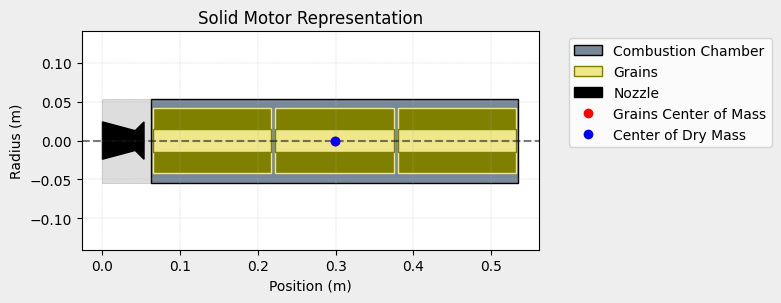

In [40]:
motor.draw()
Control_Freak.add_motor(motor, position=2.870) #m from nose tip


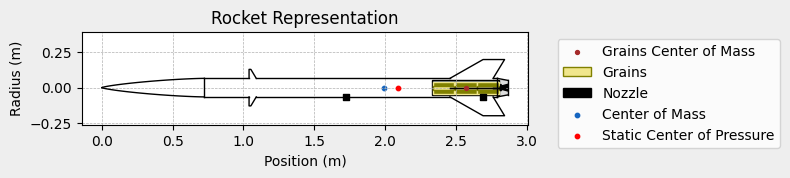

In [41]:
Control_Freak.draw()


Inertia Details

Rocket Mass: 12.000 kg (without motor)
Rocket Dry Mass: 14.799 kg (with unloaded motor)
Rocket Loaded Mass: 18.451 kg
Rocket Structural Mass Ratio: 0.802
Rocket Inertia (with unloaded motor) 11: 8.819 kg*m2
Rocket Inertia (with unloaded motor) 22: 8.819 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.060 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0655 m
Rocket Frontal Area: 0.013478 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.169 m
Rocket Center of Dry Mass - Nozzle Exit: 1.021 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.723 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.143 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 0.855/rad
Fins Lift Coefficient De

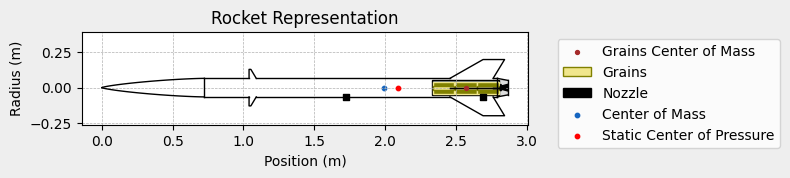


Mass Plots
----------------------------------------


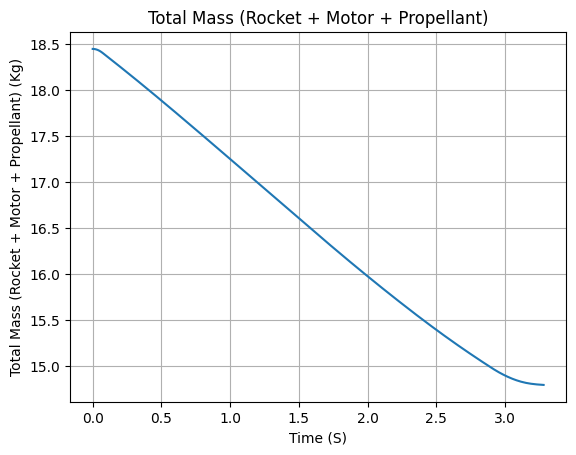

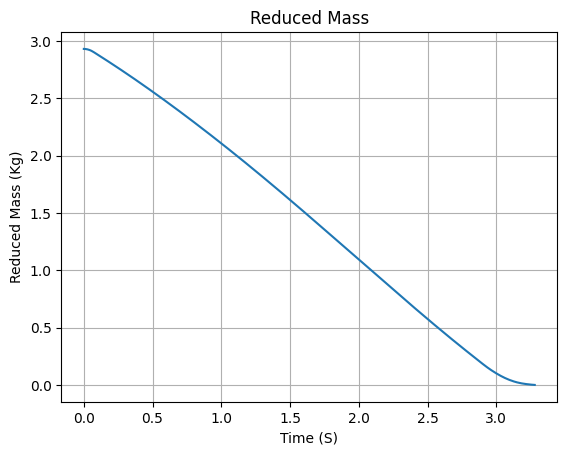


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


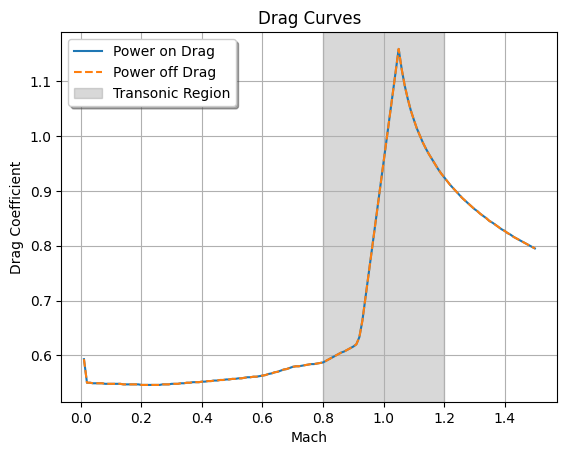


Stability Plots
--------------------


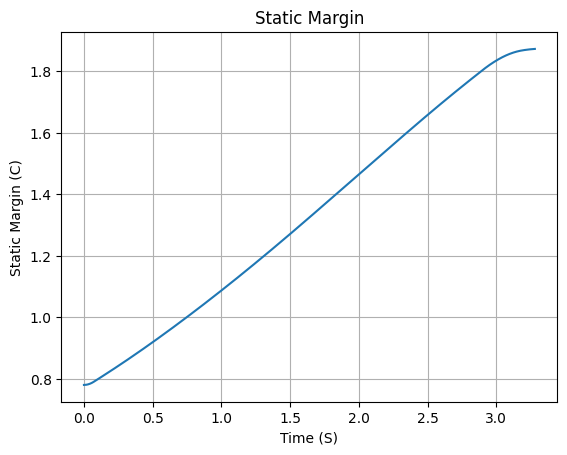

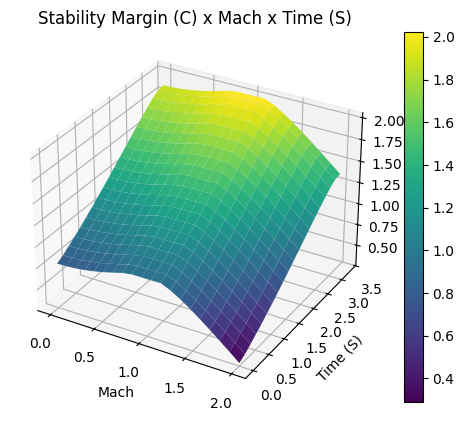


Thrust-to-Weight Plot
----------------------------------------


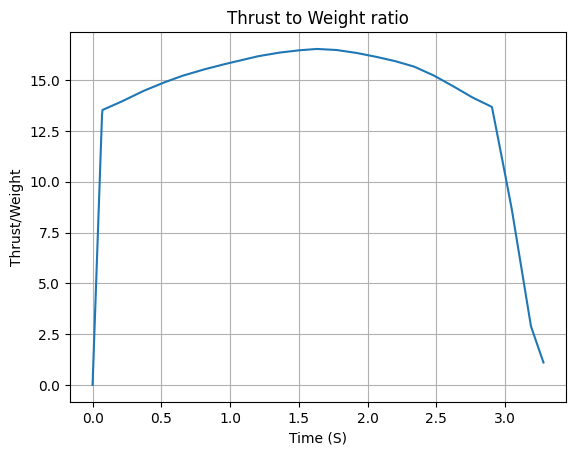

In [42]:
Control_Freak.all_info()

In [27]:
flight = rocketpy.Flight (
     rocket      = Control_Freak,
     environment = env,
     rail_length = 5.18,
     inclination = 90,    #deg — vertical launch
     heading     = 0,
     terminate_on_apogee = True,
)

In [28]:
# Velocity and speed
total_speed = flight.speed
mach_number = flight.mach_number

# Stability indicators
static_margin = flight.static_margin
stability_margin = flight.stability_margin

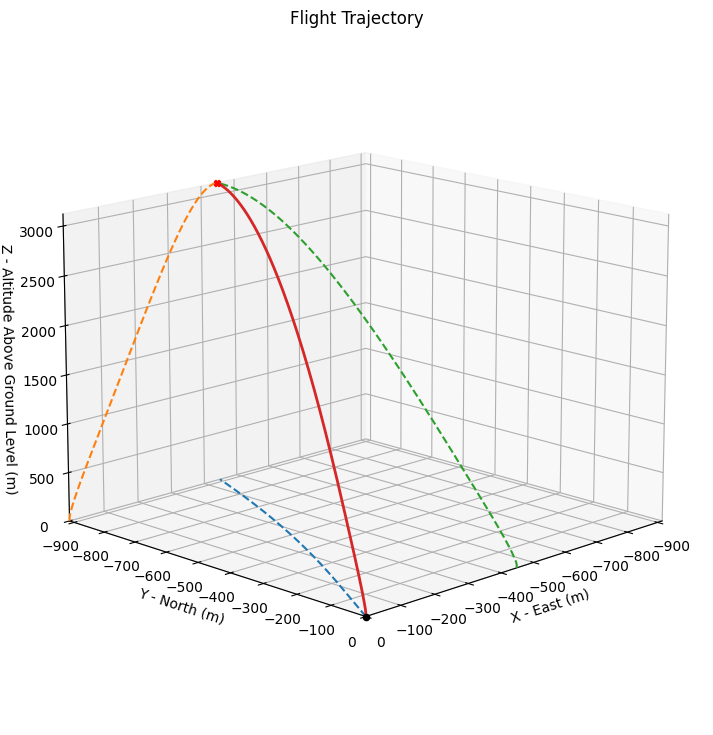

In [29]:
# 3D trajectory plot
flight.plots.trajectory_3d()



Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 217.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: -0.924 | e1: 0.000 | e2: 0.000 | e3: 0.383
Euler Angles - Spin φ : -22.50° | Nutation θ: 0.00° | Precession ψ: 337.50°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 1.404 c


Surface Wind Conditions

Frontal Surface Wind Speed: 12.33 m/s
Lateral Surface Wind Speed: -6.99 m/s


Launch Rail

Launch Rail Length: 5.18 m
Launch Rail Inclination: 90.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.308 s
Rail Departure Velocity: 30.001 m/s
Rail Departure Stability Margin: 1.487 c
Rail Departure Angle of Attack: 25.411°
Rail Departure Thrust-Weight Ratio: 12.686
Rail Departure Reynolds Number: 2.773e+05


Burn out State

Burn out time: 3.280 s
Altitude at burn out: 810.017 m (ASL) | 593.017 m (AGL)
Rocket speed at burn out: 326.246 m/s
Freestream v

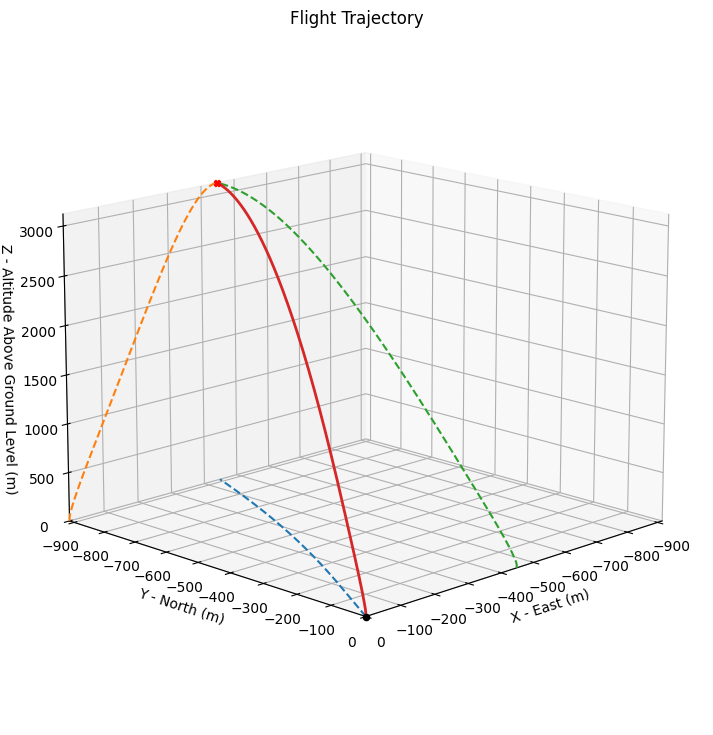



Trajectory Kinematic Plots



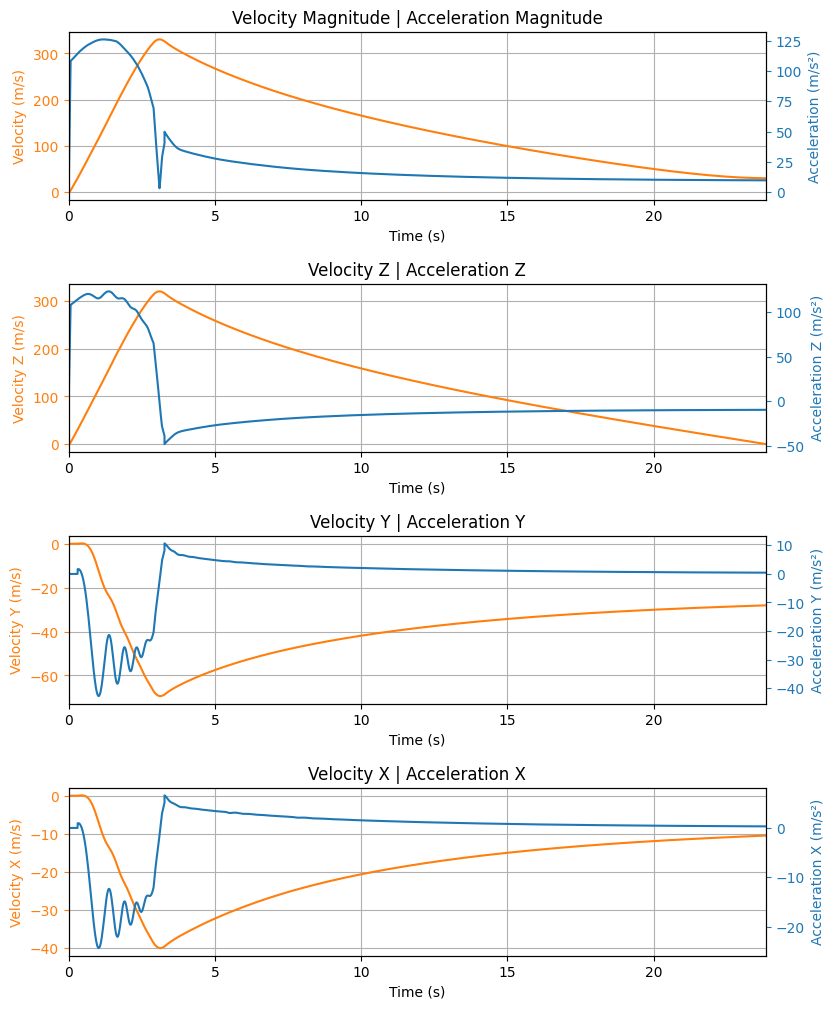



Angular Position Plots



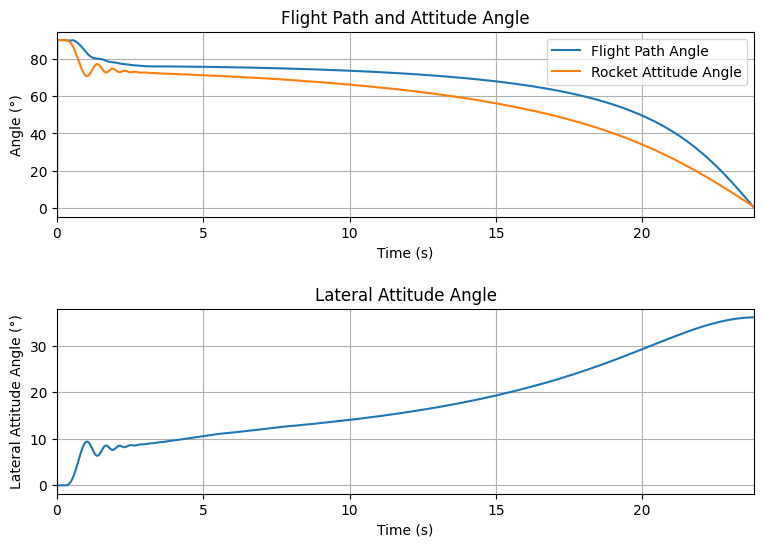



Path, Attitude and Lateral Attitude Angle plots



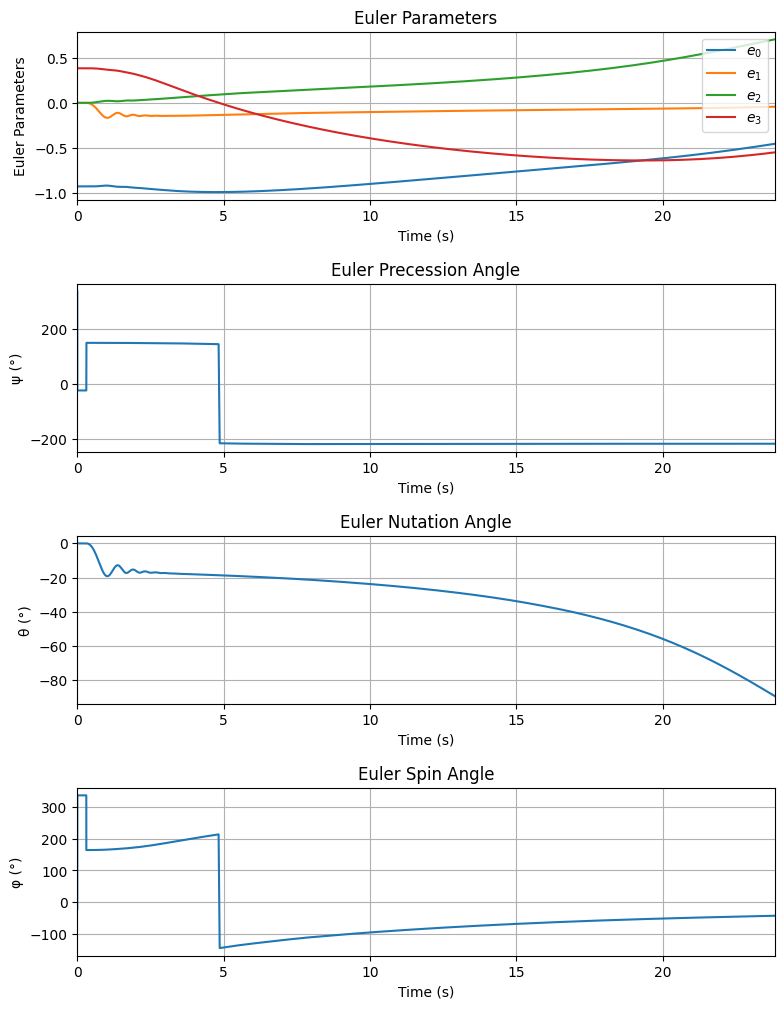



Trajectory Angular Velocity and Acceleration Plots



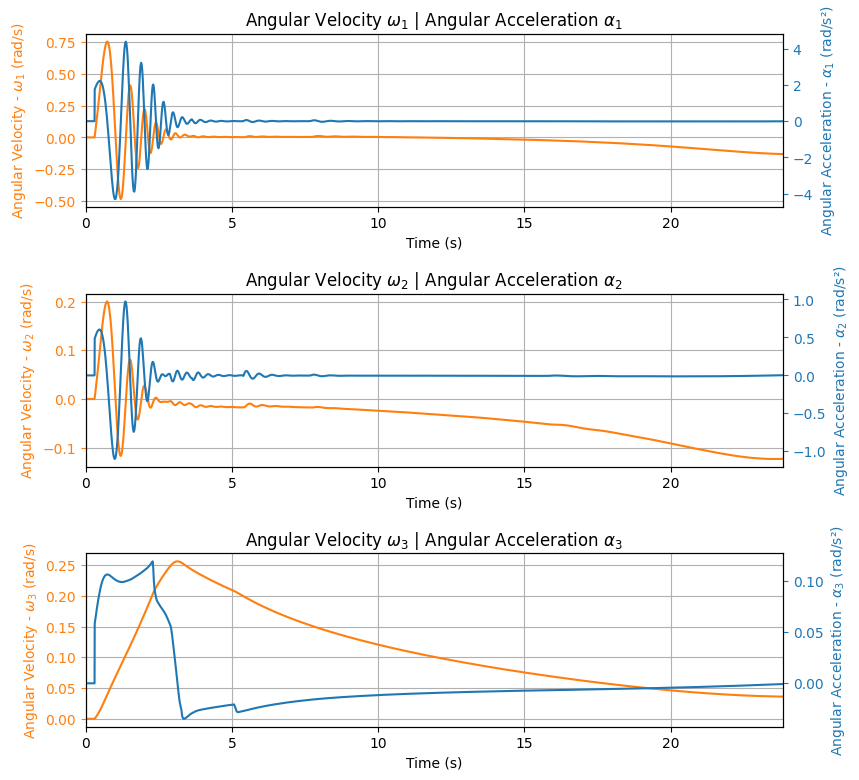



Aerodynamic Forces Plots



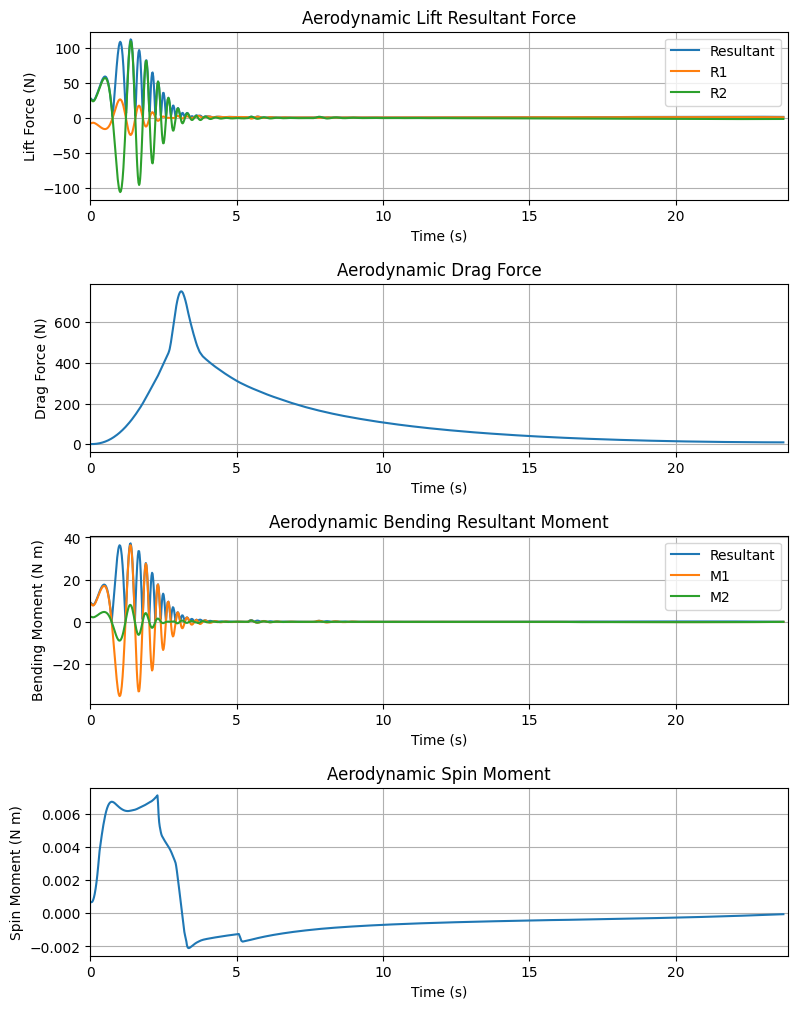



Rail Buttons Forces Plots



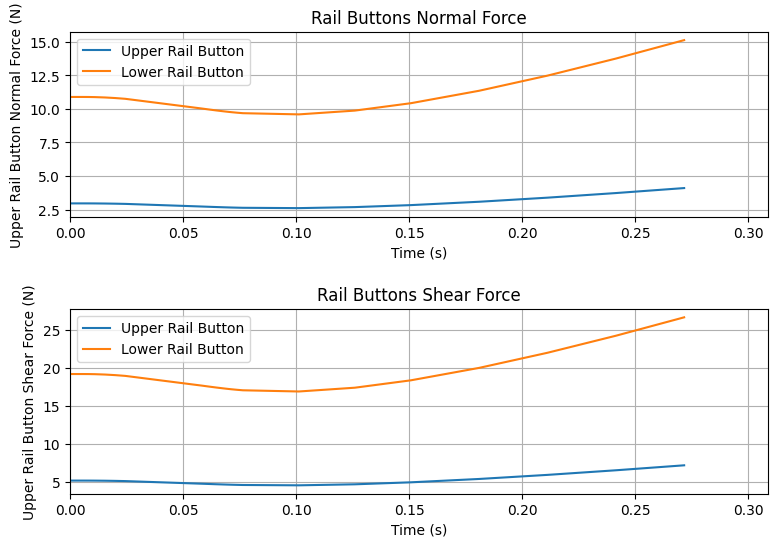



Trajectory Energy Plots



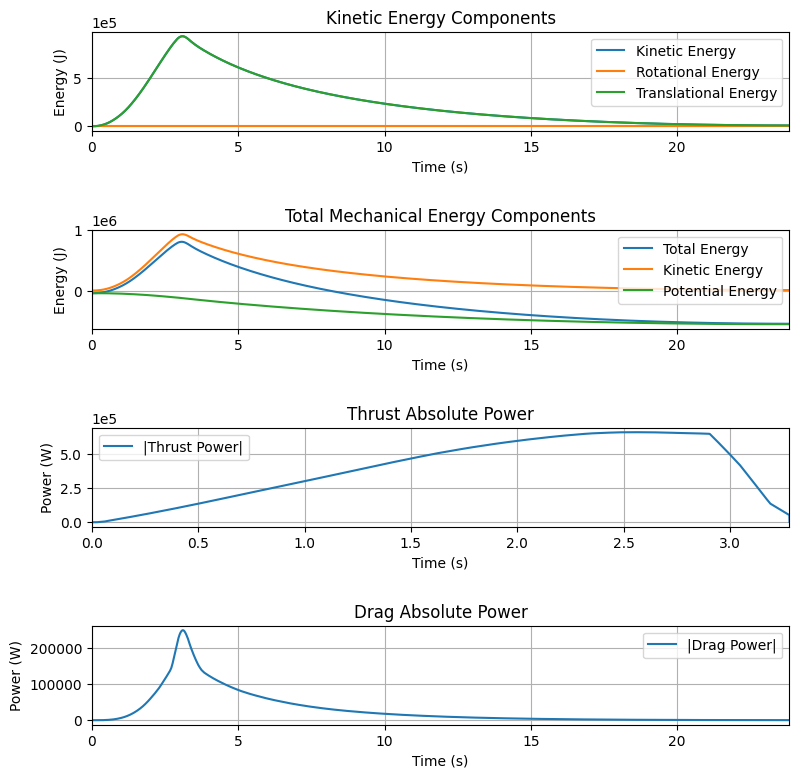



Trajectory Fluid Mechanics Plots



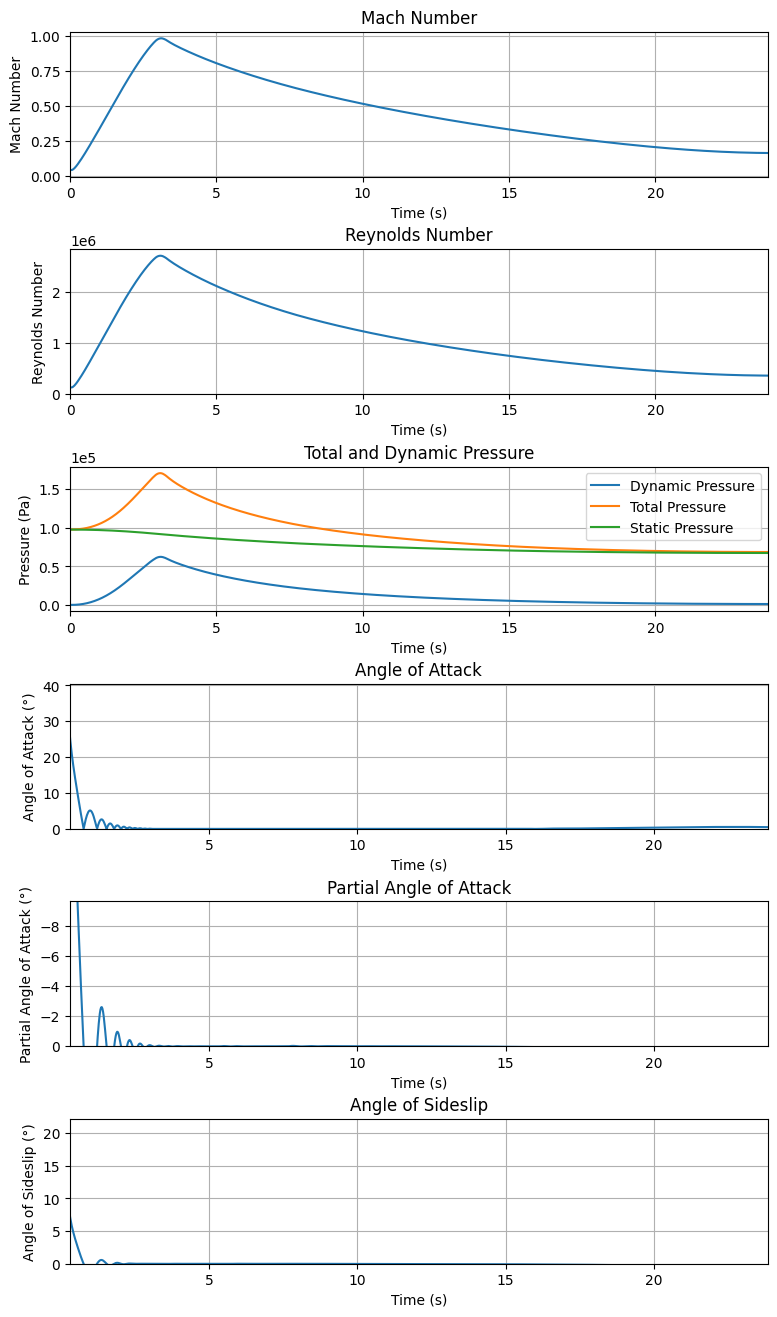



Trajectory Stability and Control Plots



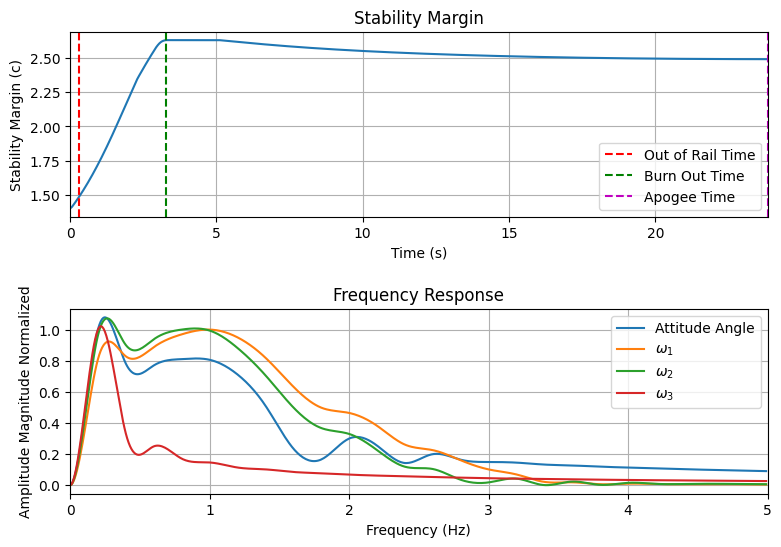



Rocket and Parachute Pressure Plots



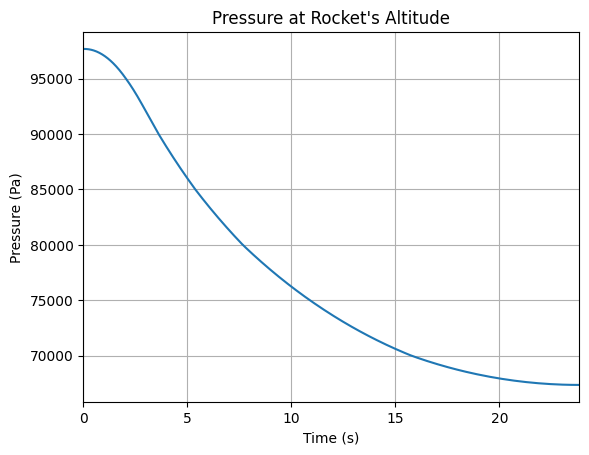


Rocket has no parachutes. No parachute plots available


In [30]:
flight.all_info()